# 01 — Data sources & coverage

**Project:** Eutrophos (OceanHackWeek 2026, Bamfield BC) — near-bottom dissolved oxygen around Vancouver Island.

This notebook documents every dataset behind the [live dashboard](https://oceanhackweek.org/ohw26_proj_eutrophos/), its provenance and licence, and what the combined spatial + temporal coverage looks like.

| File | Source | Licence |
|---|---|---|
| `site_classification.csv`, `site_daily.csv` | Ocean Networks Canada (cabled observatories & moorings) | ONC data policy |
| `cf_casts.csv` | ONC Community Fishers CTD program | ONC data policy |
| `dfo_casts.csv`, `dfo_moorings_daily.csv` | Fisheries & Oceans Canada (IOS archive) | Open Government Licence – Canada |
| `gebco_2026_*.nc` | GEBCO 2026 Grid | Public domain |
| `model_predictions.csv` | this repo, `scripts/train_oxygen_model.py` | MIT (regenerable) |

Units are mL/L throughout; status thresholds: anoxic < 0.1, hypoxic < 1.4, at-risk < 2.8.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Locate the repo root from wherever this notebook is run
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "data" / "derived").exists())
DATA = ROOT / "data" / "derived"

def dtcol(df, c):
    """Coerce a column to tz-naive datetimes regardless of source format."""
    df[c] = pd.to_datetime(df[c], utc=True, format="mixed")              .dt.tz_localize(None)
    return df

print("repo root:", ROOT)
%matplotlib inline

repo root: /home/claude/repo_check


In [2]:
cls = pd.read_csv(DATA / "site_classification.csv")
daily = dtcol(pd.read_csv(DATA / "site_daily.csv"), "date")
cf = dtcol(pd.read_csv(DATA / "cf_casts.csv"), "time")
dfo = dtcol(pd.read_csv(DATA / "dfo_casts.csv"), "time")

summary = pd.DataFrame({
    "records": [len(cls), len(daily), len(cf), len(dfo)],
    "stations/sites": [cls.site_code.nunique(), daily.site_code.nunique(),
                       cf.site_code.nunique(), dfo.site_code.nunique()],
    "first": ["-", str(daily.date.min().date()),
              str(cf.time.min().date()), str(dfo.time.min().date())],
    "last": ["-", str(daily.date.max().date()),
             str(cf.time.max().date()), str(dfo.time.max().date())],
}, index=["site_classification", "site_daily (ONC sensors)",
          "cf_casts (ONC)", "dfo_casts (DFO)"])
summary

,records,stations/sites,first,last
site_classification,43,43,-,-
site_daily (ONC sensors),54206,16,2006-02-24,2026-07-31
cf_casts (ONC),846,27,2019-01-25,2026-06-25
dfo_casts (DFO),17399,1847,2006-02-02,2024-08-21


## Where the data is

Stations over the GEBCO shaded relief that the dashboard itself uses (land transparent). Circles = ONC continuous sensor sites, triangles = ONC Community Fishers stations, small dots = DFO CTD cast stations.

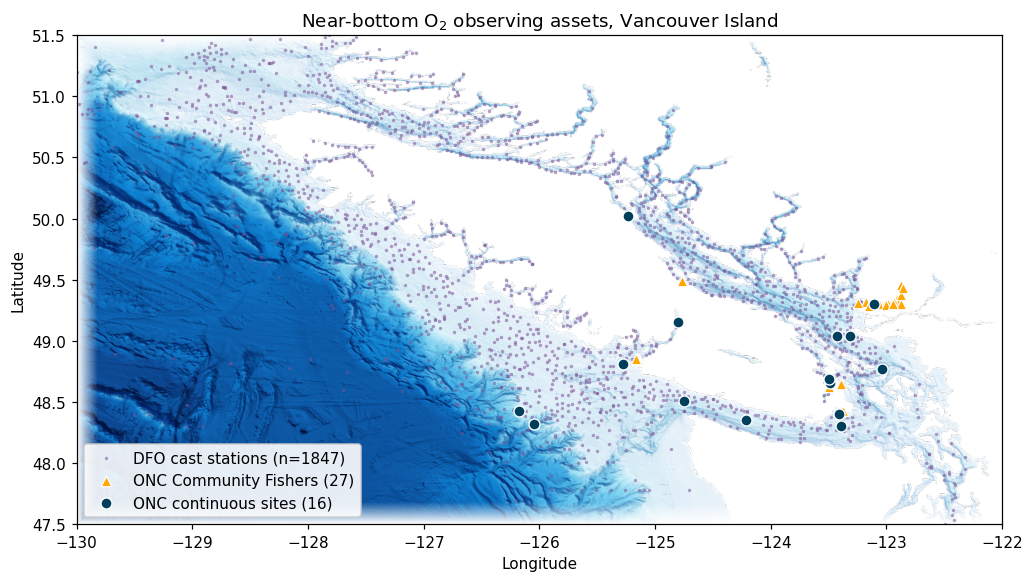

In [3]:
relief = plt.imread(ROOT / "docs" / "assets" / "gebco_relief.png")
fig, ax = plt.subplots(figsize=(9.5, 5.4), dpi=110)
ax.imshow(relief, extent=[-130, -122, 47.5, 51.5], aspect="auto")
d_st = dfo.groupby("site_code")[["lat", "lon"]].median()
ax.scatter(d_st.lon, d_st.lat, s=5, c="#7a5195", alpha=.55,
           lw=0, label=f"DFO cast stations (n={len(d_st)})")
vis = cls[cls.data_kind != "continuous"]
con = cls[cls.data_kind == "continuous"]
ax.scatter(vis.lon, vis.lat, marker="^", s=46, c="#ffa600",
           ec="white", lw=.8, label=f"ONC Community Fishers ({len(vis)})")
ax.scatter(con.lon, con.lat, s=52, c="#003f5c", ec="white",
           lw=.9, label=f"ONC continuous sites ({len(con)})")
ax.set(xlim=(-130, -122), ylim=(47.5, 51.5),
       xlabel="Longitude", ylabel="Latitude",
       title="Near-bottom O$_2$ observing assets, Vancouver Island")
ax.legend(loc="lower left", framealpha=.9)
plt.tight_layout()

## When the data was collected

RESULT casts_total=18,245 onc=846 dfo=17399


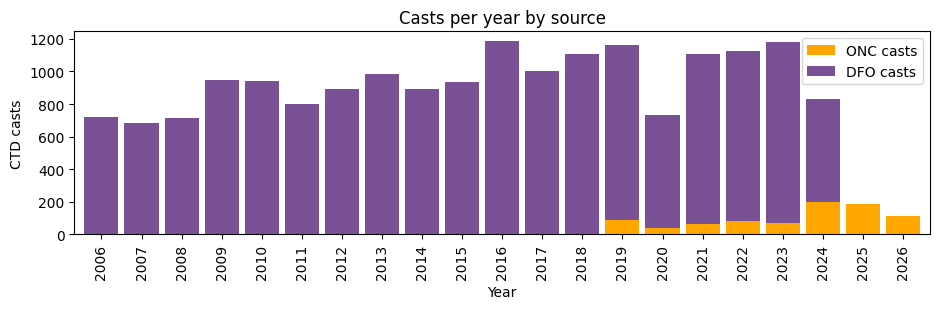

In [4]:
yr = pd.DataFrame({
    "ONC casts": cf.groupby(cf.time.dt.year).size(),
    "DFO casts": dfo.groupby(dfo.time.dt.year).size()}).fillna(0)
ax = yr.plot(kind="bar", stacked=True, figsize=(9.5, 3.2),
             color=["#ffa600", "#7a5195"], width=.85)
ax.set(xlabel="Year", ylabel="CTD casts",
       title="Casts per year by source")
plt.tight_layout()
print(f"RESULT casts_total={int(yr.values.sum()):,} "
      f"onc={int(yr['ONC casts'].sum())} dfo={int(yr['DFO casts'].sum())}")

The ONC sensor sites add daily records on top of these casts (54,206 site-days across 16 sites). Counts above are raw file contents; the dashboard shows the subset inside its study box (47.8–51.2 N, 129.5–122.5 W — e.g. 17,612 of the casts), clipping a few hundred Puget Sound stations. Together these feed one classification pipeline — reproduced from scratch in notebook 02.